# 4. Обучение по данным и сравнение с ML-моделями

Три вопроса:

1. Восстанавливаются ли CPT из данных, если структура известна?
2. Восстанавливается ли **структура**, если известны только данные?
3. Что вообще даёт байесовская сеть по сравнению с обычным классификатором?

Третий вопрос в первой версии проекта был поставлен некорректно, и это
разбирается в разделе 4.3 подробно.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.model import BayesNet
from src.network_spec import STATES, EDGES

pd.set_option("display.width", 175)
net = BayesNet.from_spec()

## 4.1 Обучение параметров при известной структуре

Сгенерируем данные из экспертной сети и посмотрим, с какого объёма
оценённые CPT сходятся к исходным.

In [2]:
big = net.sample(50000, np.random.default_rng(0))
rows = []
for n in [50, 200, 1000, 5000, 20000, 50000]:
    learned = net.fit(big.iloc[:n], alpha=1.0)
    rows.append({"n": n, **{v: round(float(np.abs(learned.cpt[v] - net.cpt[v]).max()), 3)
                            for v in ["device_cond", "pipe_cond", "failure_prob", "maintenance"]}})
conv = pd.DataFrame(rows)
print("Максимальное отклонение обученной CPT от экспертной:")
print(conv.to_string(index=False))

Максимальное отклонение обученной CPT от экспертной:
    n  device_cond  pipe_cond  failure_prob  maintenance
   50        0.350      0.417         0.417        0.350
  200        0.150      0.179         0.417        0.300
 1000        0.100      0.163         0.250        0.146
 5000        0.040      0.069         0.063        0.059
20000        0.017      0.020         0.032        0.042
50000        0.020      0.030         0.023        0.039


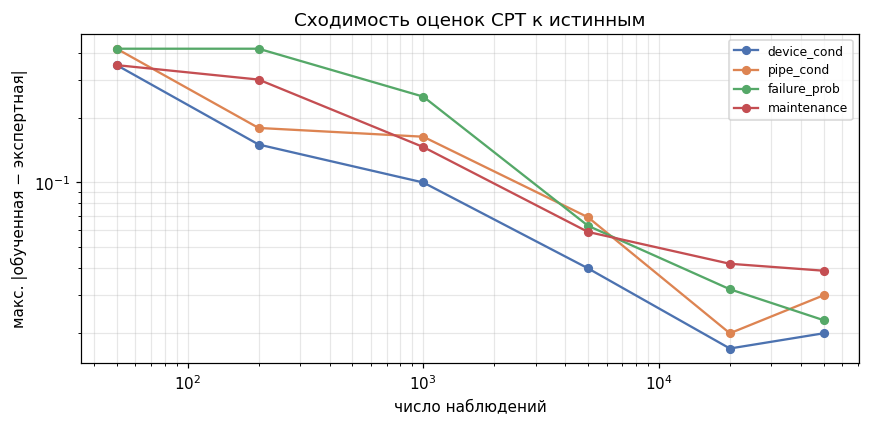

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for col, color in zip(["device_cond", "pipe_cond", "failure_prob", "maintenance"],
                      ["#4c72b0", "#dd8452", "#55a868", "#c44e52"]):
    ax.plot(conv["n"], conv[col], "-o", ms=5, color=color, label=col)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("число наблюдений")
ax.set_ylabel("макс. |обученная − экспертная|")
ax.set_title("Сходимость оценок CPT к истинным")
ax.legend(fontsize=8); ax.grid(alpha=.3, which="both")
fig.tight_layout()
plt.show()

Узлы с большим числом конфигураций родителей сходятся медленнее — у
`maintenance` и `failure_prob` по 9 строк, и на каждую нужны свои данные.
Это и есть проклятие размерности CPT в миниатюре.

## 4.2 Восстановление структуры

Теперь наоборот: данные есть, структуру не подсказываем. Жадный поиск по
BIC, реализованный на numpy (см. `src/structure_learning.py`).

In [4]:
from src.structure_learning import compare_to_expert, hill_climb, sample_size_experiment

exp = sample_size_experiment(net=net)
print(exp.to_string(index=False))

    n  дуг_найдено  скелет_F1  скелет_полнота  скелет_точность  направл_F1  BIC_обучен  BIC_эксперт
  200            6      0.632           0.462            1.000       0.105     -1417.1      -1623.3
 1000            9      0.818           0.692            1.000       0.273     -6743.7      -6940.7
 5000           13      0.846           0.846            0.846       0.231    -32697.4     -32780.2
20000           15      0.857           0.923            0.800       0.286   -129668.8    -129559.0


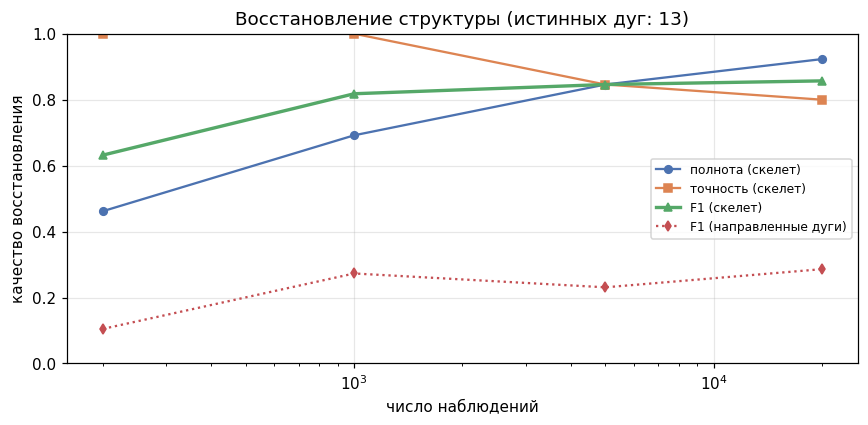

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(exp["n"], exp["скелет_полнота"], "-o", ms=5, label="полнота (скелет)", color="#4c72b0")
ax.plot(exp["n"], exp["скелет_точность"], "-s", ms=5, label="точность (скелет)", color="#dd8452")
ax.plot(exp["n"], exp["скелет_F1"], "-^", ms=5, lw=2.2, label="F1 (скелет)", color="#55a868")
ax.plot(exp["n"], exp["направл_F1"], ":d", ms=5, label="F1 (направленные дуги)", color="#c44e52")
ax.set_xscale("log")
ax.set_xlabel("число наблюдений"); ax.set_ylabel("качество восстановления")
ax.set_title(f"Восстановление структуры (истинных дуг: {len(EDGES)})")
ax.legend(fontsize=8); ax.grid(alpha=.3); ax.set_ylim(0, 1)
fig.tight_layout()
plt.show()

F1 по скелету доходит до 0.86, а направленная остаётся низкой — и это **не**
дефект алгоритма. По наблюдательным данным граф восстановим лишь с точностью
до класса Маркова-эквивалентности: направление дуги, не входящей ни в одну
v-структуру, принципиально неразличимо, такие графы задают одно и то же
распределение. Поэтому основная метрика — скелет.

Отдельная проверка: находит ли алгоритм хоть какую-то связь у температуры?

In [6]:
learned, _ = hill_climb(net.sample(5000, np.random.default_rng(42)))
cmp = compare_to_expert(learned)
for k in ["пропущено", "перевёрнуто", "лишние"]:
    print(f"{k:12s}: {', '.join(cmp[k]) if cmp[k] else '—'}")
edges = {(p, c) for c, ps in learned.items() for p in ps}
print(f"\nдуг с temperature: {sum(1 for e in edges if 'temperature' in e)} "
      "— независимое подтверждение изолированности узла")

пропущено   : pipe_cond->failure_prob, reliability->anomaly
перевёрнуто : age->device_cond, calibration->device_cond, device_cond->failure_prob, flow->anomaly, flow->pipe_cond, pipe_cond->maintenance, pressure->pipe_cond
лишние      : flow->pressure, pipe_cond->device_cond

дуг с temperature: 0 — независимое подтверждение изолированности узла


## 4.3 Сравнение с ML: сначала о том, как делать не надо

В первой версии проекта данные генерировались из той же сети, качество
которой измерялось. В такой постановке БСД оптимальна **по построению**, а
её accuracy 0.686 — не характеристика модели, а байесовский предел задачи.
Вывод «деревьям нужно на порядок больше данных» оттуда не следовал: он был
заложен в постановку.

Исправление — два режима:

* **well_specified** — данные из экспертной сети. Приводится честно
  подписанным: показывает предел, а не соревнование.
* **misspecified** — данные из **возмущённой** сети: структура верна,
  параметры нет. Ровно положение реальной экспертной модели.

И метрики — правила скоринга (log-loss, Brier), а не accuracy: продукт
системы это вероятность, на которую в решающем слое умножается цена ошибки.
Модель, угадывающая класс, но переуверенная в вероятностях, даст плохие
решения при хорошей accuracy.

In [7]:
from src.baselines import crossover, run

res_well = run("well_specified")
res_mis = run("misspecified")
print("РЕЖИМ 1 — данные из самой экспертной сети (log-loss):")
print(res_well.pivot_table(index="n_train", columns="model", values="log_loss").round(3).to_string())

РЕЖИМ 1 — данные из самой экспертной сети (log-loss):
model    DecisionTree  GradientBoosting  LogisticRegression  RandomForest  [предел] истинная сеть  БСД обученная (структура §3.2)  БСД экспертная (без обучения)
n_train                                                                                                                                                         
20             11.185             0.893               0.948         3.007                   0.798                           0.858                          0.798
50              9.818             1.358               0.976         2.396                   0.798                           0.814                          0.798
100             7.075             0.865               0.883         2.087                   0.798                           0.811                          0.798
300             3.497             0.990               0.844         2.042                   0.798                           0.804            

In [8]:
print("РЕЖИМ 2 — данные из возмущённой сети (log-loss):")
print(res_mis.pivot_table(index="n_train", columns="model", values="log_loss").round(3).to_string())

РЕЖИМ 2 — данные из возмущённой сети (log-loss):
model    DecisionTree  GradientBoosting  LogisticRegression  RandomForest  [предел] истинная сеть  БСД обученная (структура §3.2)  БСД экспертная (без обучения)
n_train                                                                                                                                                         
20              9.749             1.015               1.102         2.370                   0.947                           0.976                          0.994
50              8.027             1.006               1.065         2.009                   0.947                           0.977                          0.994
100             5.041             1.005               1.022         2.227                   0.947                           0.969                          0.994
300             3.470             0.976               0.968         1.084                   0.947                           0.951                 

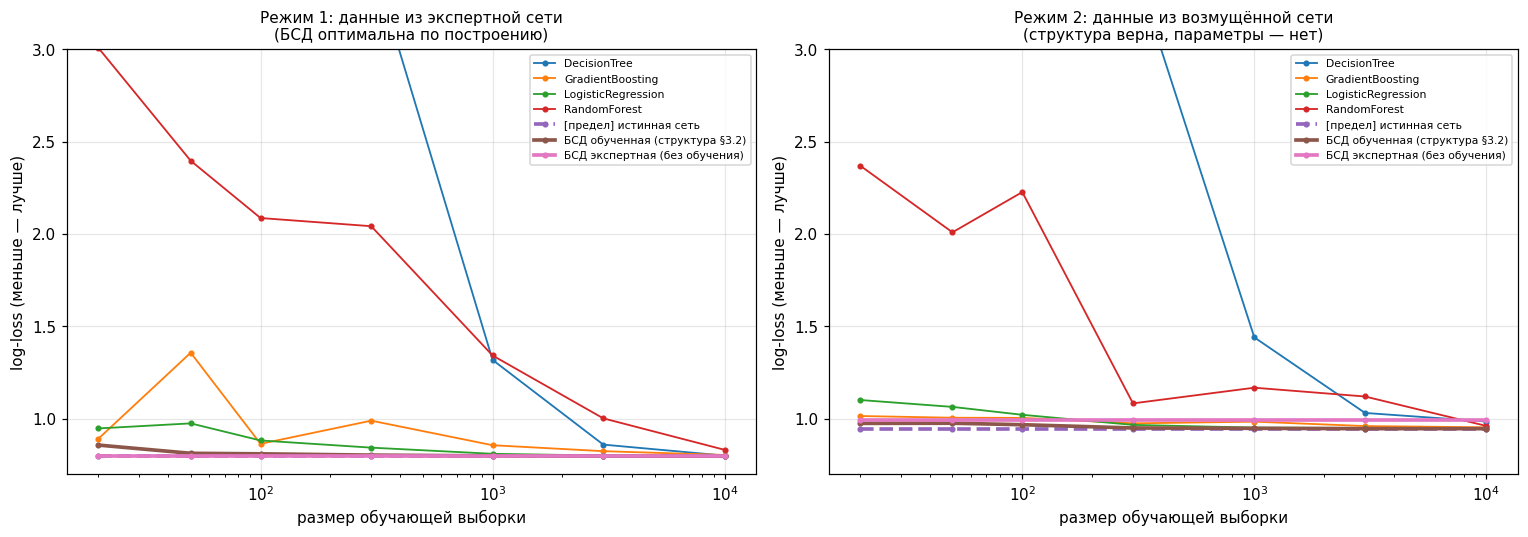

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, res, title in zip(axes, [res_well, res_mis],
                          ["Режим 1: данные из экспертной сети\n(БСД оптимальна по построению)",
                           "Режим 2: данные из возмущённой сети\n(структура верна, параметры — нет)"]):
    piv = res.pivot_table(index="n_train", columns="model", values="log_loss")
    for col in piv.columns:
        ls = "--" if col.startswith("[предел]") else "-"
        lw = 2.4 if ("БСД" in col or col.startswith("[предел]")) else 1.2
        ax.plot(piv.index, piv[col], ls, lw=lw, marker="o", ms=3, label=col)
    ax.set_xscale("log"); ax.set_ylim(0.7, 3.0)
    ax.set_xlabel("размер обучающей выборки"); ax.set_ylabel("log-loss (меньше — лучше)")
    ax.set_title(title, fontsize=10); ax.grid(alpha=.3); ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

**Главный результат — правый график.** Экспертная БСД там горизонтальна:
параметры неверны, и данные ей не помогают. Но БСД с той же структурой и
CPT, оценёнными всего по 20 наблюдениям, уже лучше и экспертной версии, и
любой модели без структуры, и быстро выходит на байесовский предел; деревьям
и бустингу для сопоставимого log-loss нужны тысячи наблюдений.

То есть выигрыш в объёме данных даёт **не** экспертная настройка
вероятностей, а экспертный причинно-следственный граф: он резко сокращает
число параметров, которые вообще нужно оценивать. Это утверждение сильнее
исходного и не зависит от того, чьи числа стояли в CPT — структура берётся
из §3.2 диплома, числа из данных.

In [10]:
print(f"Обученные CPT обгоняют экспертные начиная с n = {crossover(res_mis)}")
print("\nКалибровка вероятностей (Brier, режим 2, меньше — лучше):")
print(res_mis.pivot_table(index="n_train", columns="model", values="brier").round(3).to_string())

Обученные CPT обгоняют экспертные начиная с n = 20

Калибровка вероятностей (Brier, режим 2, меньше — лучше):
model    DecisionTree  GradientBoosting  LogisticRegression  RandomForest  [предел] истинная сеть  БСД обученная (структура §3.2)  БСД экспертная (без обучения)
n_train                                                                                                                                                         
20              0.766             0.612               0.647         0.699                   0.567                           0.581                          0.597
50              0.789             0.606               0.630         0.690                   0.567                           0.581                          0.597
100             0.705             0.598               0.604         0.662                   0.567                           0.576                          0.597
300             0.652             0.583               0.580         0.628            

## 4.4 Почему это оправдывает выбор байесовской сети

Бустинг на достаточных данных догоняет — и на этом обычно спор заканчивают.
Но у предприятия достаточных данных нет, а есть эксперт и 120 объектов в
сезон. И главное: бустинг выдаёт вероятность, а решающий слой (ноутбук 2)
требует ещё и структуры — того, что `P(состояние трубопровода)` можно
отдельно посмотреть, объяснить диспетчеру и увязать с ценой конкретного
типа ошибки. Статистически эквивалентная «чёрная» модель эту возможность
теряет.